# Personas of Explainable AI

In [ ]:
!pip install numpy
!pip install pandas
!pip install dice_ml
!pip install scikit-learn
!pip install shap
!pip install lightgbm
!pip install xgboost

## Personas 1 + 2

### Preparation of model (simulated system over a given dataset)

Initially, to simulate this persona for our studies, I decide to replicate a similiar black-box model to the automatic system of loan authorization. This clone is trained with a collected data from Kaggle, with different features of every client play the role as inputs for the system, and the output is the decision to approve or decline the loan.

In [ ]:
import dice_ml
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

np.random.seed(42)

In [35]:
df = pd.read_csv("./data1.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [36]:
print(df[df[' loan_status'] == " Rejected"].shape)
print(df[df[' loan_status'] == " Approved"].shape)

(1613, 13)
(2656, 13)


The features used to evaluated the profile of lender are: number of legal dependents (parents, children, spouse), level of education, status of self-employment, annual income, loan amount, loan term in years, credit score and several types of assets.

In [37]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


We pick a huge part from the dataset to create and train the simulating model

In [38]:
df_0 = df[df[' loan_status'] == " Rejected"].sample(n=1000, random_state=42)
df_1 = df[df[' loan_status'] == " Approved"].sample(n=2000, random_state=42)
df_init = pd.concat([df_0, df_1])
df_init[" education"] = df_init[" education"].map({" Graduate": 1, " Not Graduate": 0})
df_init[" self_employed"] = df_init[" self_employed"].map({" Yes": 1, " No": 0})
df_init[" loan_status"] = df_init[" loan_status"].map({" Approved": 1, " Rejected": 0})
df_init

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
62,63,5,0,1,8800000,28900000,6,365,24400000,8600000,27400000,4700000,0
673,674,1,0,1,5800000,13900000,6,345,4000000,9300000,20900000,5500000,0
986,987,5,0,0,700000,2400000,20,330,1300000,700000,2500000,500000,0
1102,1103,1,1,1,1600000,4900000,16,487,4300000,1100000,3900000,2000000,0
617,618,5,0,0,5400000,15100000,12,522,5200000,4700000,13900000,5700000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2213,2214,0,1,0,3000000,8100000,6,683,3200000,4900000,10200000,3200000,1
3372,3373,4,1,1,7000000,27100000,12,881,8300000,9400000,17200000,9500000,1
3026,3027,0,1,1,2700000,9700000,20,551,1300000,1300000,7100000,1600000,1
175,176,2,1,0,1800000,5300000,6,826,4500000,700000,6500000,1300000,1


In [39]:
print(df_init[df_init[' loan_status'] == " Rejected"].shape)
print(df_init[df_init[' loan_status'] == " Approved"].shape)

(0, 13)
(0, 13)


While obtaining the adjusted dataset, we apply the following classifiers:
- Random Forest
- RGBoost
- LightGBM

The model parmeters are manually adjusted so that the accuracy rate attains around 97% to 99%.

In [40]:
X = df_init.drop(columns = ["loan_id", " loan_status"])
y = df_init[" loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print((X_train.shape, y_train.shape))
print((X_test.shape, y_test.shape))

((2400, 11), (2400,))
((600, 11), (600,))


In [41]:
rf_model = RandomForestClassifier(n_estimators = 50, random_state = 42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)
print(f"Accuracy score: {accuracy_score(y_test, predictions)}")

Accuracy score: 0.9783333333333334


In [42]:
xgb_model = XGBClassifier(n_estimators = 50, learning_rate = 0.01, random_state = 42)
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
print(f"Accuracy score: {accuracy_score(y_test, predictions)}")

Accuracy score: 0.975


In [43]:
lgb_model = LGBMClassifier(n_estimators = 50, learning_rate = 0.01, random_state = 42)
lgb_model.fit(X_train, y_train)
predictions = lgb_model.predict(X_test)
print(f"Accuracy score: {accuracy_score(y_test, predictions)}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1600, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1422
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666667 -> initscore=0.693147
[LightGBM] [Info] Start training from score 0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

### Explainer for client

To build an explainer for clients who get refused, we use the remained examples of rejection from the initial dataset to build the expainer.

In [44]:
df_rest = df.drop(df_init.index)
df_rest

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
12,13,3,Not Graduate,Yes,5000000,11600000,16,311,6400000,9600000,14600000,4300000,Rejected
13,14,2,Graduate,Yes,9100000,31500000,14,679,10800000,16600000,20900000,5000000,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4257,4258,0,Graduate,No,9700000,27500000,18,343,13400000,16500000,20000000,8200000,Rejected
4259,4260,0,Not Graduate,Yes,4500000,11500000,14,509,13400000,2300000,15400000,5900000,Rejected
4262,4263,5,Graduate,No,1300000,3000000,20,540,1000000,2300000,3200000,1900000,Rejected
4263,4264,3,Graduate,No,5000000,12700000,14,865,4700000,8100000,19500000,6300000,Approved


In [45]:
rejected_examples = df_rest[df_rest[' loan_status'] == " Rejected"].sample(n=100, random_state=42)
rejected_examples = rejected_examples.drop(columns=["loan_id", " loan_status"])
rejected_examples[" education"] = rejected_examples[" education"].map({" Graduate": 1, " Not Graduate": 0})
rejected_examples[" self_employed"] = rejected_examples[" self_employed"].map({" Yes": 1, " No": 0})
#rejected_examples[" loan_status"] = rejected_examples[" loan_status"].map({" Approved": 1, " Rejected": 0})
rejected_examples 

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
2626,4,1,1,2100000,7700000,8,493,4300000,400000,4400000,1300000
724,1,0,0,4200000,16200000,14,391,5800000,2100000,14100000,2600000
1017,1,0,1,2500000,6700000,2,502,3400000,2600000,9400000,1400000
2776,4,1,1,7900000,30700000,10,322,10600000,13200000,30300000,6300000
4257,0,1,0,9700000,27500000,18,343,13400000,16500000,20000000,8200000
...,...,...,...,...,...,...,...,...,...,...,...
1941,2,1,0,400000,1300000,16,507,200000,200000,1500000,300000
2019,0,0,1,3300000,9600000,8,465,6100000,700000,9700000,2000000
1985,5,1,1,7300000,19600000,10,373,10400000,4700000,19500000,10600000
2261,1,0,1,5300000,14600000,20,508,11200000,2800000,17000000,4600000


#### Counterfactual explanation

The explanation in this case requires the following constraints:
- Level of interpretability: Local interpretability on a single example
- Constraint: Privacy of users and accountability

Solution: Counterfactual explanation: Choose an example which brings better result:
$$
e^*=\arg\operatorname*{opt}_ec_x(e)
$$
Where $c_x(e)$ is the function of cost and $f(x)\neq f(e)$

In [46]:
def client_explainer(df, model, example, features, label, desired_class, method="random", noCFs=1):
    d = dice_ml.Data(dataframe=df, continuous_features=features, outcome_name=label)
    m = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method=method)
    dice_exp = exp.generate_counterfactuals(example, total_CFs=noCFs, desired_class=desired_class)
    return dice_exp

In [47]:
print(df.columns.to_list())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [48]:
train_data_dice = X_train.copy()
train_data_dice[" loan_status"] = y_train

continuous_features = df.columns.to_list()
continuous_features.remove("loan_id")
continuous_features.remove(" loan_status")

query_instance = rejected_examples.iloc[[0]]

explanation = client_explainer(train_data_dice, rf_model, query_instance, continuous_features, " loan_status", 1)

explanation.visualize_as_dataframe(show_only_changes=False)

100%|██████████| 1/1 [00:00<00:00,  1.82it/s]

Query instance (original outcome : 0)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,4,1,1,2100000,7700000,8,493,4300000,400000,4400000,1300000,0



Diverse Counterfactual set (new outcome: 1)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,4,1,1,2100000,7700000,8,866,4300000,400000,4400000,1300000,1


In [49]:
explanation.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,4,1,1,2100000,7700000,8,493,4300000,400000,4400000,1300000,0



Diverse Counterfactual set (new outcome: 1)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-,-,-,-,-,-,866,-,-,-,-,1


#### Metrics over explanation

In [50]:
explain = explanation._cf_examples_list[0].final_cfs_df
explain

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,4,1,1,2100000,7700000,8,866,4300000,400000,4400000,1300000,1


**Sparsity**: How many features should be changed to get a better result:
$$
\delta_S(x,e)=\|e-x\|_0=\sum_i\Bbb 1_{e_i\neq x_i}
$$

In [51]:
def sparsity(explanation, example, features):
    score = 0
    for i in features:
        if explanation[i].values[0] != example[i].values[0]:
            score += 1
    return score

print(f"Sparsity score: {sparsity(explain, query_instance, continuous_features)}")

Sparsity score: 1


**Proximity**: How much is the explanation near the primary example:
$$
\delta_P(x,e)=\sum_i\frac{|e_i-x_i|}{\sigma_i}
$$

In [52]:
def proximity(df, features, example, explanation):
    score = 0
    for i in features:
        score += abs(explanation[i].values[0] - example[i].values[0])/(df[i].std() + 1e-15)
    return score

print(f"Proximity score: {proximity(train_data_dice, continuous_features, query_instance, explain)}")

Proximity score: 2.1817238400813856


### Explainer for auditor

The explanation in this case requires the following constraints:
- Level of interpretability: Model-level Global interpretability
- Constraint: Non-accessability to the system, Fairness

Solutions:
- Feature importance: Which features are led in priority for the decision of loan approval.
- Calculate the fairness: Demographic parity ratio and p-rule

#### Global SHAP explanation

In [53]:
def auditor_explainer(model, df, features, label):
    background_data = shap.sample(df, 100)
    exp = shap.KernelExplainer(model.predict, background_data, feature_names=features, output_names=label)
    return exp

100%|██████████| 100/100 [01:38<00:00,  1.02it/s]


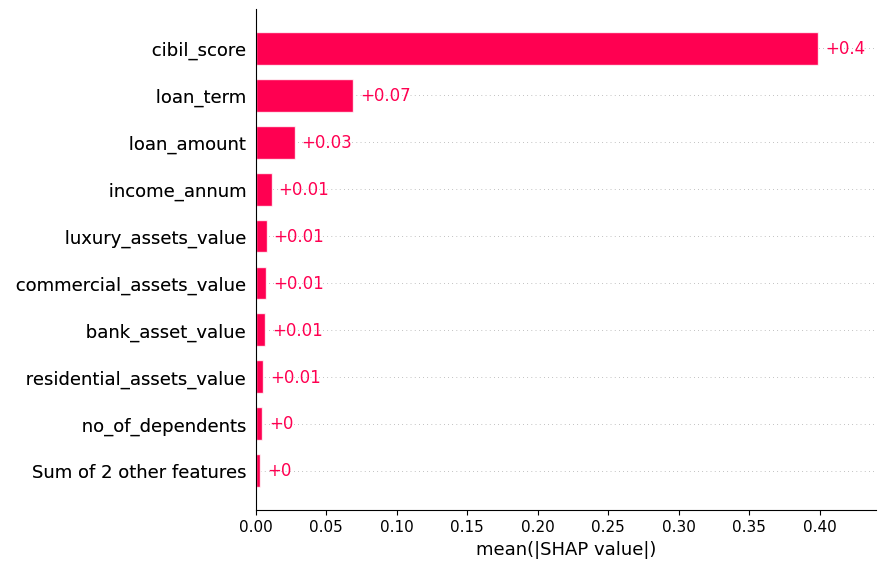

In [54]:
sample_to_test = X_train.sample(100, random_state=42)
shap_values = auditor_explainer(rf_model, X_train, continuous_features, " loan_status")
shap.plots.bar(shap_values(sample_to_test))

#### Demographic parity ratio and p-value

Within a binary setting of outcome, the test of equity based on categories of clients depends on the interesting studied feature. Considering $\hat Y=\{0,1\}$ as the outcome of the model, and $S$ as the feature which we categorize the data along.

Therefore, in case $S$ is a binary feature, the demographic parity ratio becomes:
$$
\frac{P(\hat Y=1|S=1)}{P(\hat Y=1|S=0)}
$$

To generalize the problem, we consider a threshold $\delta$ over $S$. The ratio becomes:
$$
\frac{P(\hat Y=1|S\geq\delta)}{P(\hat Y=1|S<\delta)}
$$

We have $p$-rule:
$$
p=\min\left\{\frac{P(\hat Y=1|S=1)}{P(\hat Y=1|S=0)},\frac{P(\hat Y=1|S=0)}{P(\hat Y=1|S=1)}\right\}=\max\left\{\frac{P(\hat Y=1|S\geq\delta)}{P(\hat Y=1|S<\delta)},\frac{P(\hat Y=1|S<\delta)}{P(\hat Y=1|S\geq\delta)}\right\}
$$
- If $p=100\%$: totally fair
- If $p=0\%$: totally unfair

In [55]:
def p_rule(df, requested_feature, threshold, label, positive_class=1):
    group_geq = df[df[requested_feature] >= threshold]
    group_less = df[df[requested_feature] < threshold]
    p_geq = (group_geq[label] == positive_class).mean()
    p_less = (group_less[label] == positive_class).mean()
    if p_geq == 0 and p_less == 0:
        return 100.0
    if p_geq == 0 or p_less == 0:
        return 0.0
    p = min(p_geq / p_less, p_less / p_geq)
    return p * 100

In [58]:
data_fairness = X_train.copy()
data_fairness[" loan_status"] = y_train

print(f"p value for p rule over the feature of self-employment: {p_rule(data_fairness, " self_employed", 1, " loan_status")}")
print(f"p value for p rule over the feature of level of education: {p_rule(data_fairness, " education", 1, " loan_status")}")

p value for p rule over the feature of self-employment: 96.72126444436702
p value for p rule over the feature of level of education: 97.28729963008632
